Architecture One:
* Uses only a singular convolutional layer
* Tested using different loss functions (weighted & unweighted)
* Tested using different optimizer functions (SGD, Adam)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os
from PIL import Image

from myDataset import *

# imports loss, accuracy and confusion matrix plots
from MetricMethods import *

# imports train, test methods
from ArchitectureMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.empty_cache()

# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/Custom All
/user/HS401/ob00564/Documents/COM3001
cuda


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9602616].


Train set length: 3241
Test set length: 404
Validation set length: 408
torch.Size([3, 224, 224]) 0
0


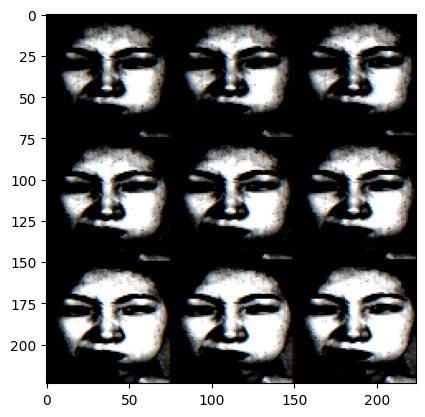

In [2]:
# Dataset Creation
train_dataset = myDataset(directory = "Custom All/DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "Custom All/DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "Custom All/DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

# DataLoader Creation
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers= 8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers= 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers= 8)

# View shape of data
train_iter = iter(train_dataset)
img, label = next(train_iter)
print(img.shape, label)

np_img = img.numpy()
print(label)
plt.imshow(np_img.reshape((224,224,3)))



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ArchitectureOne(nn.Module):
    
    def __init__(self):
        super(ArchitectureOne, self).__init__()

        # Conv1 Output: [224x224x32]
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.batch_norm = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)  
        

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 112 * 112, 7)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm(x)
        x = self.relu(x)
        x = self.pool(x)
        

        x = self.flatten(x)
        x = self.fc(x)
        return x


100%|██████████| 203/203 [00:15<00:00, 13.01it/s]


Adam
Epoch 1/50, Training Loss: 1.5027, Validation Loss: 1.3038
Epoch 1/50, Training Acc: 47.04775588396278, Validation Accuracy: 56.25
SGD
Epoch 1/50, Training Loss: 1.5561, Validation Loss: 1.3206
Epoch 1/50, Training Acc: 43.4147509578544, Validation Accuracy: 56.25


100%|██████████| 203/203 [00:04<00:00, 48.38it/s]


Adam
Epoch 2/50, Training Loss: 1.1699, Validation Loss: 1.1132
Epoch 2/50, Training Acc: 58.7883141762452, Validation Accuracy: 62.74038461538461
SGD
Epoch 2/50, Training Loss: 1.2133, Validation Loss: 1.1272
Epoch 2/50, Training Acc: 57.04022988505747, Validation Accuracy: 60.33653846153846


100%|██████████| 203/203 [00:04<00:00, 48.28it/s]


...

Adam
Epoch 48/50, Training Loss: 0.0954, Validation Loss: 0.9939
Epoch 48/50, Training Acc: 97.87561576354679, Validation Accuracy: 74.03846153846155
SGD
Epoch 48/50, Training Loss: 0.2524, Validation Loss: 0.7437
Epoch 48/50, Training Acc: 94.30418719211822, Validation Accuracy: 75.72115384615384


100%|██████████| 203/203 [00:04<00:00, 47.58it/s]


Adam
Epoch 49/50, Training Loss: 0.0877, Validation Loss: 0.9782
Epoch 49/50, Training Acc: 98.42980295566502, Validation Accuracy: 73.5576923076923
SGD
Epoch 49/50, Training Loss: 0.2507, Validation Loss: 0.7724
Epoch 49/50, Training Acc: 93.6576354679803, Validation Accuracy: 73.79807692307693


100%|██████████| 203/203 [00:04<00:00, 47.12it/s]


Adam
Epoch 50/50, Training Loss: 0.0942, Validation Loss: 0.9891
Epoch 50/50, Training Acc: 97.81403940886699, Validation Accuracy: 75.96153846153845
SGD
Epoch 50/50, Training Loss: 0.2431, Validation Loss: 0.7485
Epoch 50/50, Training Acc: 94.55733442802409, Validation Accuracy: 74.51923076923077
Models saved successfully!


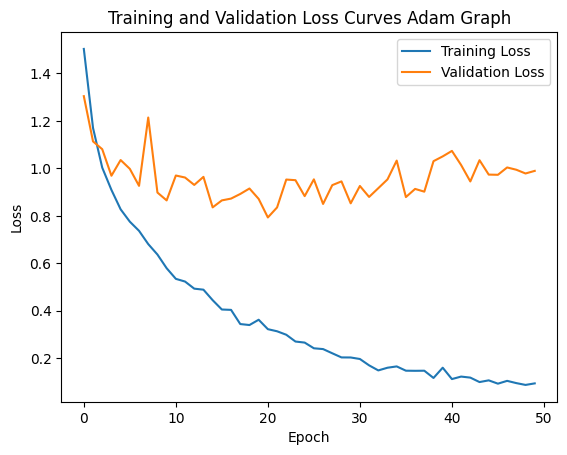

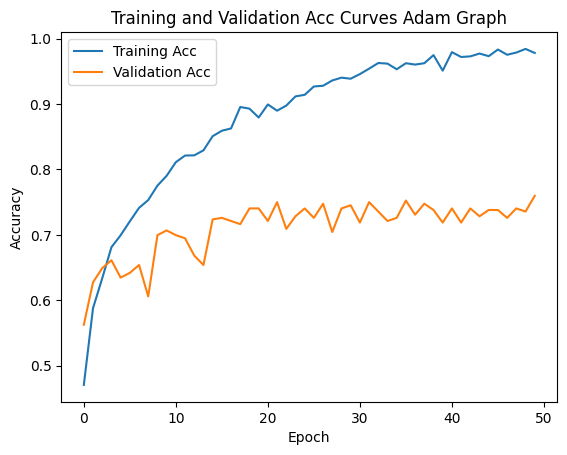

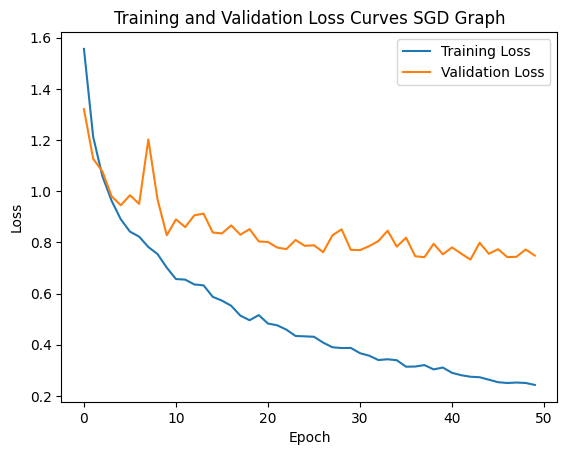

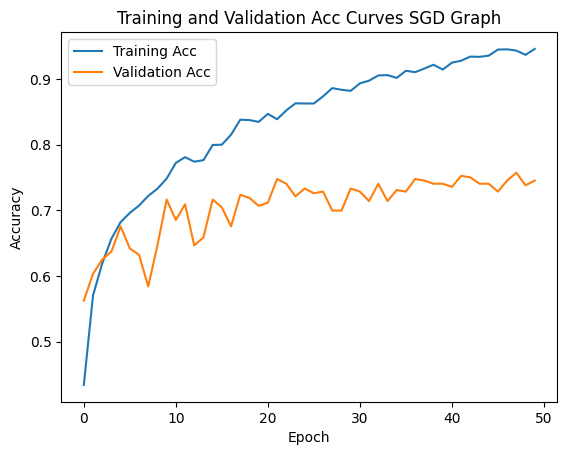

In [4]:
# Train and Test of ArchitectureOne using *un-weighted* Cross-Entropy Loss function

# Model Instance
model_one_a = ArchitectureOne().to(device)
model_one_b = ArchitectureOne().to(device)

# Epochs
num_epochs = 50

# Optimizer
unweighted_adamOptimizer = optim.Adam(model_one_a.parameters(), lr=0.00001, weight_decay=0.01)
unweighted_sgdOptimizer = optim.SGD(model_one_b.parameters(), lr=0.00001, momentum=0.9)

# Loss Function
criterion = nn.CrossEntropyLoss()

(unweighted_train_losses_a, unweighted_val_losses_a, unweighted_train_accuracy_a, unweighted_val_accuracy_a, 
 unweighted_train_losses_b, unweighted_val_losses_b, unweighted_train_accuracy_b, unweighted_val_accuracy_b) = train(model_one_a, model_one_b, device, train_loader, val_loader, 
                                                                                                                        unweighted_adamOptimizer, unweighted_sgdOptimizer, lr_scheduler_a= None, lr_scheduler_b=None, 
                                                                                                                        num_epochs=num_epochs, criterion = criterion, 
                                                                                                                        name_a='Custom All/Architecture One/Unweighted Architecture One Adam.pth', 
                                                                                                                        name_b='Custom All/Architecture One/Unweighted Architecture One SGD.pth')

# Print metrics a
lossPlot(unweighted_train_losses_a, unweighted_val_losses_a, 'Adam Graph')
accuracyPlot(unweighted_train_accuracy_a, unweighted_val_accuracy_a,'Adam Graph')

# Print metrics b
lossPlot(unweighted_train_losses_b, unweighted_val_losses_b,'SGD Graph')
accuracyPlot(unweighted_train_accuracy_b, unweighted_val_accuracy_b, 'SGD Graph')

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


100%|██████████| 203/203 [00:04<00:00, 47.54it/s]


Adam
Epoch 1/50, Training Loss: 1.5918, Validation Loss: 1.2618
Epoch 1/50, Training Acc: 45.015736179529284, Validation Accuracy: 53.84615384615385
SGD
Epoch 1/50, Training Loss: 1.6915, Validation Loss: 1.3031
Epoch 1/50, Training Acc: 39.38149972632731, Validation Accuracy: 53.84615384615385


100%|██████████| 203/203 [00:04<00:00, 47.23it/s]


Adam
Epoch 2/50, Training Loss: 1.1992, Validation Loss: 1.1343
Epoch 2/50, Training Acc: 58.17939244663383, Validation Accuracy: 58.65384615384615
SGD
Epoch 2/50, Training Loss: 1.2774, Validation Loss: 1.2077
Epoch 2/50, Training Acc: 55.35372194854954, Validation Accuracy: 54.08653846153846


...

Adam
Epoch 48/50, Training Loss: 0.0850, Validation Loss: 0.9447
Epoch 48/50, Training Acc: 98.0603448275862, Validation Accuracy: 75.48076923076923
SGD
Epoch 48/50, Training Loss: 0.2826, Validation Loss: 0.7923
Epoch 48/50, Training Acc: 92.7716201423098, Validation Accuracy: 73.3173076923077


100%|██████████| 203/203 [00:04<00:00, 47.19it/s]


Adam
Epoch 49/50, Training Loss: 0.0756, Validation Loss: 1.0274
Epoch 49/50, Training Acc: 98.98399014778325, Validation Accuracy: 75.96153846153845
SGD
Epoch 49/50, Training Loss: 0.2871, Validation Loss: 0.8308
Epoch 49/50, Training Acc: 92.33374384236454, Validation Accuracy: 71.63461538461539


100%|██████████| 203/203 [00:04<00:00, 47.46it/s]


Adam
Epoch 50/50, Training Loss: 0.0845, Validation Loss: 1.0536
Epoch 50/50, Training Acc: 98.30665024630541, Validation Accuracy: 74.75961538461539
SGD
Epoch 50/50, Training Loss: 0.2874, Validation Loss: 0.7522
Epoch 50/50, Training Acc: 92.34742747673782, Validation Accuracy: 73.5576923076923
Models saved successfully!


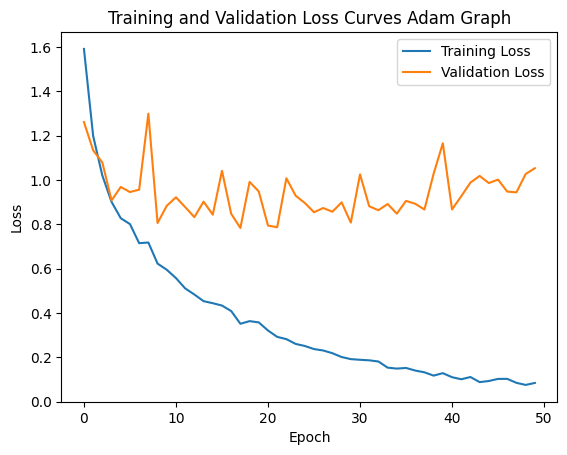

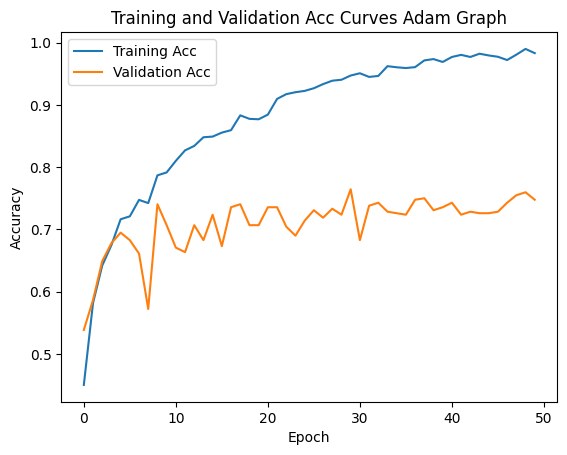

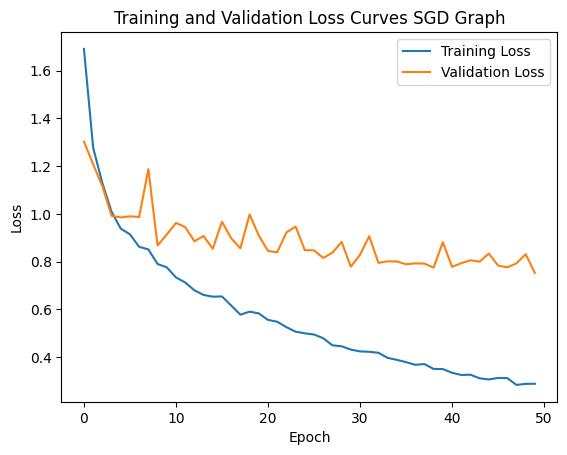

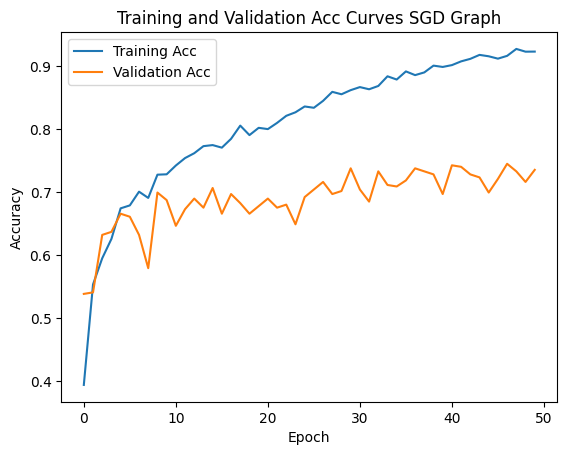

In [5]:
# Train and Test of ArchitectureOne using *weighted* Cross-Entropy Loss function

model_one_weighted = ArchitectureOne().to(device)

# Model Instance
model_one_weighted_a = ArchitectureOne().to(device)
model_one_weighted_b = ArchitectureOne().to(device)

# Epochs
num_epochs = 50

# Optimizer
weighted_adamOptimizer = optim.Adam(model_one_weighted_a.parameters(), lr=0.00001, weight_decay=0.01)
weighted_sgdOptimizer = optim.SGD(model_one_weighted_b.parameters(), lr=0.00001, momentum=0.9)

# Loss Function
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))

(weighted_train_losses_a, weighted_val_losses_a, weighted_train_accuracy_a, weighted_val_accuracy_a, 
 weighted_train_losses_b, weighted_val_losses_b, weighted_train_accuracy_b, weighted_val_accuracy_b) = train(model_one_weighted_a, model_one_weighted_b, device, train_loader, val_loader, 
                                                                                                                    weighted_adamOptimizer, weighted_sgdOptimizer, lr_scheduler_a= None, lr_scheduler_b=None, 
                                                                                                                    num_epochs=num_epochs, criterion=criterion, 
                                                                                                                    name_a= 'Custom All/Architecture One/Weighted Architecture One Adam.pth', 
                                                                                                                    name_b= 'Custom All/Architecture One/Weighted Architecture One SGD.pth')

# Print metrics a
lossPlot(weighted_train_losses_a, weighted_val_losses_a, 'Adam Graph')
accuracyPlot(weighted_train_accuracy_a, weighted_val_accuracy_a, 'Adam Graph')

# Print metrics b
lossPlot(weighted_train_losses_b, weighted_val_losses_b, 'SGD Graph')
accuracyPlot(weighted_train_accuracy_b, weighted_val_accuracy_b, 'SGD Graph')

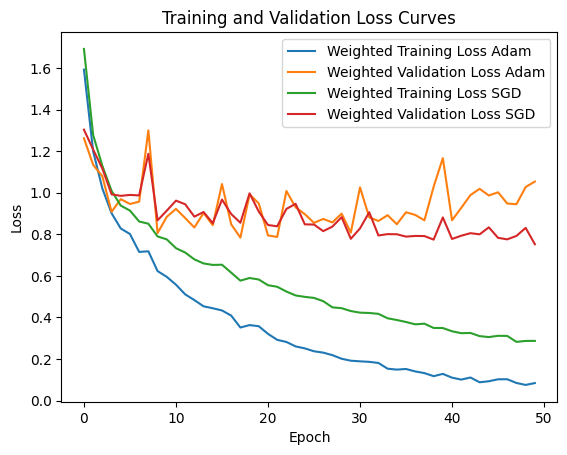

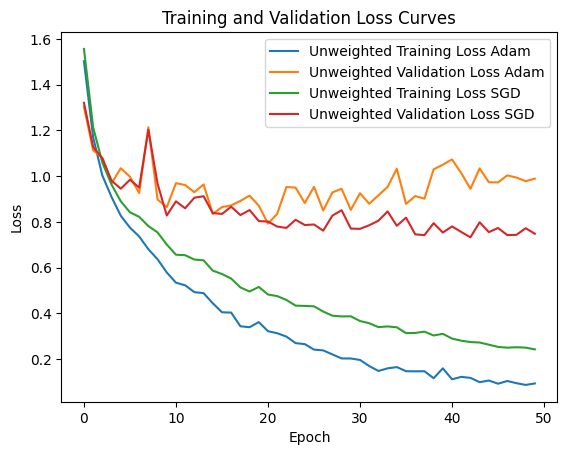

Adam unweighted Split Loss: 1.1134, Adam unweighted Split Accuracy: 74.02%
SGD unweighted Split Loss: 0.7993, SGD unweighted Split Accuracy: 74.02%
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Adam weighted Split Loss: 1.1629, Adam weighted Split Accuracy: 73.04%
SGD weighted Split Loss: 0.7690, SGD weighted Split Accuracy: 75.74%
Fin


In [6]:
def lossPlotUnWeighted():
    plt.plot(unweighted_train_losses_a, label='Unweighted Training Loss Adam')
    plt.plot(unweighted_val_losses_a, label='Unweighted Validation Loss Adam')

    plt.plot(unweighted_train_losses_b, label='Unweighted Training Loss SGD')
    plt.plot(unweighted_val_losses_b, label='Unweighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():
    plt.plot(weighted_train_losses_a, label='Weighted Training Loss Adam')
    plt.plot(weighted_val_losses_a, label='Weighted Validation Loss Adam')

    plt.plot(weighted_train_losses_b, label='Weighted Training Loss SGD')
    plt.plot(weighted_val_losses_b, label='Weighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

criterion = nn.CrossEntropyLoss()
test(model_one_a, device, criterion, test_loader, 'Adam unweighted Split')
test(model_one_b, device, criterion, test_loader, 'SGD unweighted Split')

criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
test(model_one_weighted_a, device, criterion, test_loader, 'Adam weighted Split')
test(model_one_weighted_b, device, criterion, test_loader, 'SGD weighted Split')

print('Fin')

Unweighted Adam Test Loss: 1.1134, Unweighted Adam Test Accuracy: 74.02%
              precision    recall  f1-score   support

       Anger     0.6304    0.5800    0.6042        50
     Disgust     0.7778    0.6863    0.7292        51
        Fear     0.5676    0.4375    0.4941        48
   Happiness     0.9245    0.9423    0.9333        52
     Sadness     0.6078    0.6458    0.6263        48
    Surprise     0.7500    0.8333    0.7895        54
     Neurtal     0.7931    0.8762    0.8326       105

    accuracy                         0.7402       408
   macro avg     0.7216    0.7145    0.7156       408
weighted avg     0.7340    0.7402    0.7347       408



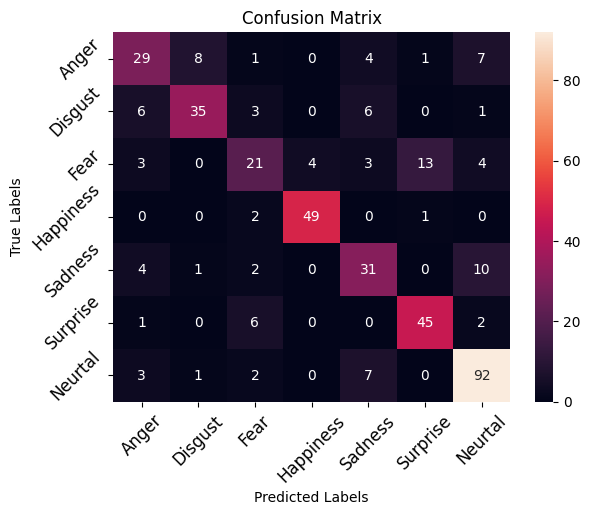

In [7]:
criterion = nn.CrossEntropyLoss()
a_unweighted_y_true, a_unweighted_y_pred, _ = test(myModel=model_one_a,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted Adam Test')
confusionMatrixPlot(a_unweighted_y_true, a_unweighted_y_pred)

Unweighted SGD Test Loss: 0.7993, Unweighted SGD Test Accuracy: 74.02%
              precision    recall  f1-score   support

       Anger     0.6304    0.5800    0.6042        50
     Disgust     0.7778    0.6863    0.7292        51
        Fear     0.5676    0.4375    0.4941        48
   Happiness     0.9245    0.9423    0.9333        52
     Sadness     0.6078    0.6458    0.6263        48
    Surprise     0.7500    0.8333    0.7895        54
     Neurtal     0.7931    0.8762    0.8326       105

    accuracy                         0.7402       408
   macro avg     0.7216    0.7145    0.7156       408
weighted avg     0.7340    0.7402    0.7347       408



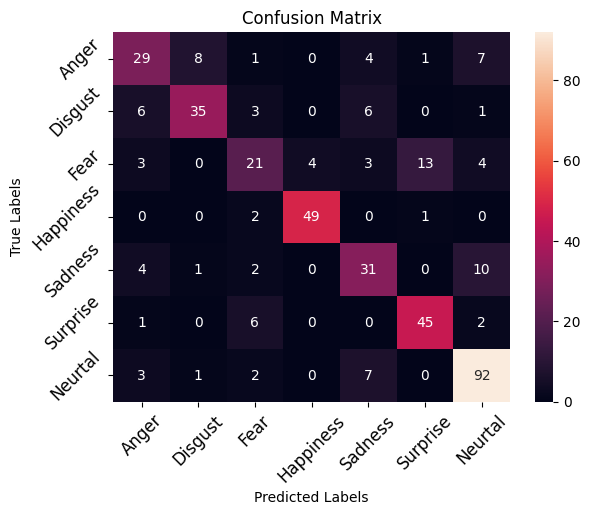

In [8]:
criterion = nn.CrossEntropyLoss()
b_unweighted_y_true, b_unweighted_y_pred, _ = test(myModel=model_one_b,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted SGD Test')
confusionMatrixPlot(y_true=a_unweighted_y_true, y_pred=a_unweighted_y_pred)

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Weighted Adam Test Loss: 1.1629, Weighted Adam Test Accuracy: 73.04%
              precision    recall  f1-score   support

       Anger     0.6410    0.5000    0.5618        50
     Disgust     0.7727    0.6667    0.7158        51
        Fear     0.5122    0.4375    0.4719        48
   Happiness     0.8868    0.9038    0.8952        52
     Sadness     0.6250    0.6250    0.6250        48
    Surprise     0.7368    0.7778    0.7568        54
     Neurtal     0.7857    0.9429    0.8571       105

    accuracy                         0.7304       408
   macro avg     0.7086    0.6934    0.6977       408
weighted avg     0.7217    0.7304    0.7222       408



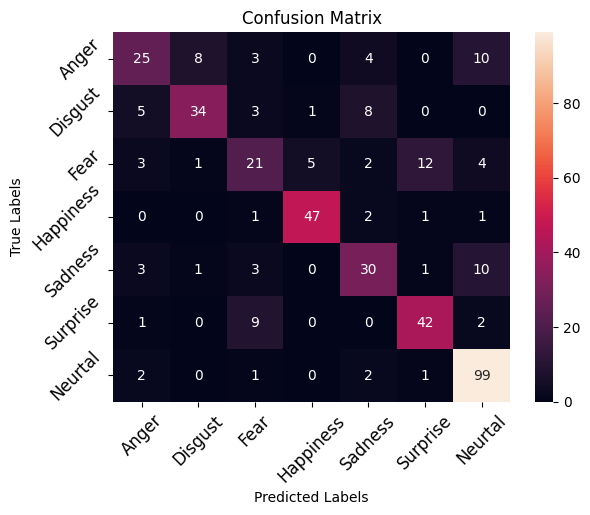

In [9]:
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
a_weighted_y_true, a_weighted_y_pred, _ = test(myModel=model_one_weighted_a,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted Adam Test')
confusionMatrixPlot(a_weighted_y_true, a_weighted_y_pred)

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Weighted SGD Test Loss: 0.7690, Weighted SGD Test Accuracy: 75.74%
              precision    recall  f1-score   support

       Anger     0.6226    0.6600    0.6408        50
     Disgust     0.7609    0.6863    0.7216        51
        Fear     0.6154    0.5000    0.5517        48
   Happiness     0.9245    0.9423    0.9333        52
     Sadness     0.6818    0.6250    0.6522        48
    Surprise     0.7538    0.9074    0.8235        54
     Neurtal     0.8241    0.8476    0.8357       105

    accuracy                         0.7574       408
   macro avg     0.7405    0.7384    0.7370       408
weighted avg     0.7537    0.7574    0.7534       408



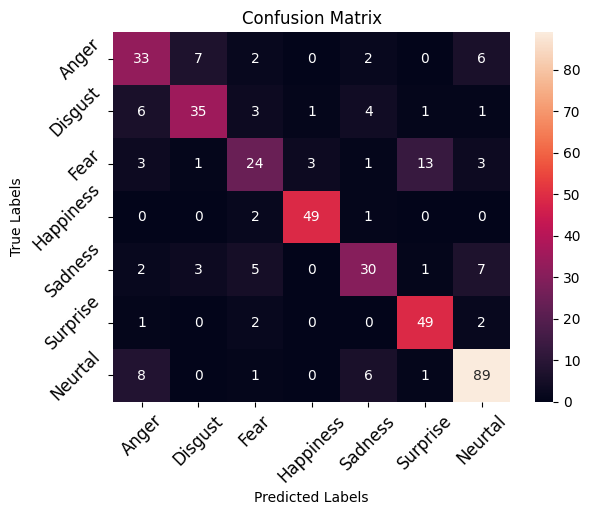

In [10]:
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
b_weighted_y_true, b_weighted_y_pred, _ = test(myModel=model_one_weighted_b,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted SGD Test')
confusionMatrixPlot(b_weighted_y_true, b_weighted_y_pred)

**Analysis & Improvements**:

Using figures above, we can see the training and validation loss begin to diverge after only a few epochs of training.

Using figures above (unweighted):
* Adam:
    * Training not very stable after 4th epoch overfitting
    * Learning Rate needs further adjustment - implement scheduler
* SGD:
    * Training not stable after 4th epoch overfitting

Using figures above (weighted):
* Adam:
    * Training unstable stable & overfitting
* SGD:
    * Training is slightly unstable & minimal overfitting, however large loss

The training loss begins to decrease, whilst the validation loss begins to increase, this indicates a few things:
* Overfitting: the loss curves are divering from one another, and training curve is always decreasing (model is memorizing the data)
* Simple Model: the model is too siple, its unable to capture underlying features 
* Small Learning Rate: steps taken to converge are too small, not able to learn well enough

Steps taken to improve:
* Increase regularization: dropout, weight decay
* Increase model complexity: more conv layers
* Use a larger learning rate, implement a lr_scheduler to step learning rate 

